# WFS controls for operation at ALS beamline 5.3.1
walangrizolli@lbl.gov, francisho@lbl.gov, khchan@lbl.gov, awojdyla@lbl.gov

We want to: 
+ collect data with various bender settings
+ collect data with various photon energy
+ FrankotChellapize the whole shebang


## Setting up epics/ophyd/bluesky/tiled

In [2]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
import sys
sys.path.append('/home/bl531/python/bluesky-web/queue-server/startup_bl531/')

from h01 import mono_energy

In [3]:
Obender.low_limit_travel.set(-2000)

Status(obj=EpicsSignal(read_pv='bl531_esp300:m101_bend_um.LLM', name='bender_um_low_limit_travel', parent='bender_um', value=-2000.0, timestamp=1773555298.069768, tolerance=1e-05, auto_monitor=True, string=False, write_pv='bl531_esp300:m101_bend_um.LLM', limits=False, put_complete=False), done=False, success=False)

In [4]:
from ophyd import ADComponent
from ophyd import ImagePlugin
from ophyd import SingleTrigger
from ophyd import Component, DetectorBase, CamBase, EpicsSignal, EpicsSignalRO
from ophyd.areadetector.filestore_mixins import FileStoreTIFFIterativeWrite
from ophyd.areadetector.plugins import TIFFPlugin
import os

BASLER_FILES_ROOT = "/mnt/data531"
BASLER_TEST_IMAGE_DIR = "20251113_test/%Y/%m/%d"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs


############### Basler TIFF Plugin ################

class BaslerTIFFPlugin(FileStoreTIFFIterativeWrite, TIFFPlugin):

    def describe(self):
        ret = super().describe()
        key = self.parent._image_name

        color_mode = self.parent.cam.color_mode.get(as_string=True)
        num_images = self.parent.cam.num_images.get()
        height = self.array_size.height.get()
        width  = self.array_size.width.get()

        if color_mode == 'Mono':
            ret[key]['shape'] = [num_images, height, width]
        elif color_mode in ['RGB1', 'Bayer']:
            ret[key]['shape'] = [num_images, height, width, 3]
        else:
            raise RuntimeError(f"Unexpected color_mode: {color_mode!r}")

        # dtype mapping
        cam_dtype = self.data_type.get(as_string=True)
        type_map = {
            'UInt8':   '|u1',
            'UInt16':  '<u2',
            'Float32': '<f4',
            'Float64': '<f8',
            'Int32':   '<i4',
        }
        if cam_dtype in type_map:
            ret[key].setdefault('dtype_str', type_map[cam_dtype])

        return ret


############### Basler Cam ################

class BaslerCam(CamBase):
    """
    Basler camera CAM plugin.
    Extends CamBase with Basler-specific PVs.
    CamBase already provides: acquire, acquire_time, acquire_period,
    num_images, image_mode, trigger_mode, color_mode, data_type, etc.
    Only add PVs that CamBase does NOT already define.
    """

    # Basler-specific PVs not in CamBase
    pixel_format  = Component(EpicsSignal,   'PixelFormat',  string=True)
    gain          = Component(EpicsSignal,   'Gain')
    exposure_auto = Component(EpicsSignal,   'ExposureAuto', string=True)
    gain_auto     = Component(EpicsSignal,   'GainAuto',     string=True)

    # Readback for acquire so SingleTrigger can poll it
    acquire_rbv   = Component(EpicsSignalRO, 'Acquire_RBV')


############### Basler Detector ################

class BaslerDetector(SingleTrigger, DetectorBase):
    """
    Complete Basler area-detector device.
    Uses SingleTrigger mixin so bp.count() / bp.scan() work out of the box.
    """

    cam   = ADComponent(BaslerCam,          'cam1:')
    image = ADComponent(ImagePlugin,        'image1:')
    tiff  = ADComponent(
        BaslerTIFFPlugin,
        'TIFF1:',
        write_path_template=os.path.join(BASLER_FILES_ROOT, BASLER_TEST_IMAGE_DIR),
        read_path_template=os.path.join(BASLER_FILES_ROOT, BASLER_TEST_IMAGE_DIR),
    )


############### Instantiation ################

try:
    basler_camera = BaslerDetector('BL531acA5427:', name='basler_camera')

    # Stage signals — set before each acquisition, restored after
    basler_camera.cam.stage_sigs['image_mode']    = 'Single'
    basler_camera.cam.stage_sigs['num_images']    = 1
    basler_camera.cam.stage_sigs['acquire_time']  = 10
    basler_camera.cam.stage_sigs['acquire_period'] = 1

    basler_camera.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_camera.tiff.stage_sigs['enable']        = 1
    basler_camera.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_camera.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_camera.read_attrs      = ['tiff']
    basler_camera.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

Basler camera connected successfully.


In [5]:
import time
import threading
import re
import numpy as np
from ophyd import Device, Component
from ophyd.status import DeviceStatus


# ============================================================
# Helper: parse LabView float responses safely
# ============================================================

def parse_labview_float(s):
    """Parse a LabView TCP response like '10.000000' or '0.000000!0' to float."""
    s = str(s).strip()
    m = re.match(r'^[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
    if m:
        return float(m.group(0))
    raise ValueError(f"Cannot parse float from {s!r}")


# ============================================================
# BCS Motor ophyd Device — Tiled/bluesky compatible
# ============================================================

class BCSMotor(Device):
    """
    Ophyd Device wrapping a single BCS LabView TCP motor axis.
    Fully compatible with bluesky RunEngine and Tiled.

    Parameters
    ----------
    bcs : connection
        Your existing LabView TCP connection object.
    motor_id : str
        The motor identifier string used by BCS (e.g. 'Galil x.20 A').
    settle_time : float
        Seconds to wait after reaching target before marking done. Default 0.5s.
    tolerance : float
        Position tolerance in engineering units. Default 0.01.
    units : str
        Engineering units string for Tiled metadata. Default 'mm'.
    name : str
        Ophyd device name (required).
    """

    def __init__(
        self,
        bcs,
        motor_id,
        settle_time=0.5,
        tolerance=0.01,
        units='mm',
        *args,
        **kwargs,
    ):
        super().__init__(prefix='', *args, **kwargs)
        self._bcs       = bcs
        self._motor_id  = motor_id
        self._settle_time = settle_time
        self._tolerance   = tolerance
        self._units       = units
        self._target      = None   # last commanded target
        self._set_status  = None   # current move DeviceStatus

    # ----------------------------------------------------------
    # Core read/describe — what bluesky records per event
    # ----------------------------------------------------------

    def get(self):
        """Return current motor position as float."""
        raw = self._bcs.GetMotorPos(self._motor_id)
        return parse_labview_float(raw)

    def read(self):
        """
        Called by bluesky at every event point.
        Must return dict of {signal_name: {'value': ..., 'timestamp': ...}}
        """
        pos = self.get()
        ts  = time.time()
        return {
            f'{self.name}':         {'value': pos,           'timestamp': ts},
            f'{self.name}_setpoint': {'value': self._target if self._target is not None else pos,
                                      'timestamp': ts},
        }

    def describe(self):
        """
        Called by bluesky at run start.
        Must return dict matching the keys in read().
        """
        return {
            f'{self.name}': {
                'source':   f'BCS:{self._motor_id}',
                'dtype':    'number',
                'shape':    [],
                'units':    self._units,
                'lower_ctrl_limit': 0.0,
                'upper_ctrl_limit': 0.0,
            },
            f'{self.name}_setpoint': {
                'source':   f'BCS:{self._motor_id}:setpoint',
                'dtype':    'number',
                'shape':    [],
                'units':    self._units,
                'lower_ctrl_limit': 0.0,
                'upper_ctrl_limit': 0.0,
            },
        }

    # ----------------------------------------------------------
    # Configuration read/describe — static metadata for Tiled
    # ----------------------------------------------------------

    def read_configuration(self):
        """
        Called by bluesky at run start/stop.
        Returns slow/static configuration values.
        """
        return {
            f'{self.name}_motor_id':    {'value': self._motor_id,    'timestamp': time.time()},
            f'{self.name}_settle_time': {'value': self._settle_time, 'timestamp': time.time()},
            f'{self.name}_tolerance':   {'value': self._tolerance,   'timestamp': time.time()},
            f'{self.name}_units':       {'value': self._units,       'timestamp': time.time()},
        }

    def describe_configuration(self):
        """
        Called by bluesky at run start.
        Must return dict matching the keys in read_configuration().
        """
        return {
            f'{self.name}_motor_id': {
                'source': f'BCS:{self._motor_id}:config',
                'dtype':  'string',
                'shape':  [],
                'units':  None,
            },
            f'{self.name}_settle_time': {
                'source': f'BCS:{self._motor_id}:config',
                'dtype':  'number',
                'shape':  [],
                'units':  's',
            },
            f'{self.name}_tolerance': {
                'source': f'BCS:{self._motor_id}:config',
                'dtype':  'number',
                'shape':  [],
                'units':  self._units,
            },
            f'{self.name}_units': {
                'source': f'BCS:{self._motor_id}:config',
                'dtype':  'string',
                'shape':  [],
                'units':  None,
            },
        }

    # ----------------------------------------------------------
    # Hints — tells Tiled/bluesky which field is the primary one
    # ----------------------------------------------------------

    @property
    def hints(self):
        """
        Tells bluesky/Tiled which field to use as the primary
        axis in LivePlot, BestEffortCallback, and Tiled plots.
        """
        return {'fields': [self.name]}

    # ----------------------------------------------------------
    # Move / set
    # ----------------------------------------------------------

    def set(self, target, timeout=120):
        """
        Move the motor to target position.
        Returns a DeviceStatus that completes when the motor
        reaches the target (within tolerance) plus settle time.
        The RunEngine will block until this status is marked done.
        """
        self._target = target
        st = DeviceStatus(self, timeout=timeout)
        self._set_status = st

        def _move():
            try:
                # Issue the move command
                print(f"[BCSMotor] {self.name}: moving to {target:.4f} {self._units}")
                self._bcs.MoveMotor(self._motor_id, target)

                # Wait before first readback so the motor controller
                # has time to update its position
                time.sleep(2)

                # Step 1: poll until motor is within tolerance of target
                deadline = time.time() + timeout
                pos = self.get()
                while time.time() < deadline:
                    try:
                        pos = self.get()
                    except Exception as e:
                        print(f"[BCSMotor] position read error: {e}")
                        time.sleep(0.1)
                        continue

                    remaining = abs(pos - target)
                    # print(f"[BCSMotor] {self.name}: pos={pos:.4f}, "
                    #     f"target={target:.4f}, remaining={remaining:.4f}")

                    if remaining <= self._tolerance:
                        break

                    time.sleep(0.05)
                else:
                    # Loop exhausted without reaching target
                    st.set_exception(
                        TimeoutError(
                            f"[BCSMotor] {self.name}: timed out after {timeout}s. "
                            f"Last pos={pos:.4f}, target={target:.4f}"
                        )
                    )
                    return

                # Step 2: settle time
                # print(f"[BCSMotor] {self.name}: within tolerance, "
                #     f"settling for {self._settle_time}s...")
                time.sleep(self._settle_time)

                # Step 3: final position readback
                final = self.get()
                print(f"[BCSMotor] {self.name}: done. "
                    f"Final position = {final:.4f} {self._units}")

                # Mark done — RunEngine unblocks here
                st.set_finished()

            except Exception as e:
                st.set_exception(e)

        t = threading.Thread(target=_move, daemon=True)
        t.start()
        return st

    # ----------------------------------------------------------
    # Stage / unstage (called by bluesky at scan start/end)
    # ----------------------------------------------------------

    def stage(self):
        """Called by bluesky before a scan starts."""
        return [self]

    def unstage(self):
        """Called by bluesky after a scan ends."""
        return [self]

    # ----------------------------------------------------------
    # Stop
    # ----------------------------------------------------------

    def stop(self, *, success=False):
        """Stop the motor immediately (called on RE.abort())."""
        try:
            self._bcs.StopMotor(self._motor_id)
        except Exception as e:
            print(f"[BCSMotor] stop error: {e}")

    # ----------------------------------------------------------
    # Convenience
    # ----------------------------------------------------------

    @property
    def position(self):
        """Current motor position as float."""
        return self.get()

    def __repr__(self):
        try:
            pos = self.get()
            return (f"BCSMotor(name={self.name!r}, "
                    f"motor_id={self._motor_id!r}, "
                    f"position={pos:.4f} {self._units})")
        except Exception:
            return (f"BCSMotor(name={self.name!r}, "
                    f"motor_id={self._motor_id!r})")

In [6]:
import sys
import bcs_tcp

# ============================================================
# BCS TCP connection (same as your existing setup)
# ============================================================

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (same as before)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Quick sanity check
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# ============================================================
# Instantiate BCSMotor ophyd objects
# ============================================================

bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# ============================================================
# Quick checks
# ============================================================

print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

linear stage position is 13.800138 mm
Linear motor position : 13.800138 mm
Rotary motor position : 0.0 deg
BCSMotor(name='bcs_linear_motor', motor_id='Galil x.20 A', position=13.8001 mm)
BCSMotor(name='bcs_rotary_motor', motor_id='Galil x.20 B', position=0.0000 mm)


In [14]:
# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

from bluesky import RunEngine

RE = RunEngine({})


# Send all metadata/data captured to the BestEffortCallback.


from databroker.v2 import temp
db = temp()

# Insert all metadata/data captured into db.
RE.subscribe(db.v1.insert)


from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri
#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
# tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)
RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

# add 'baseline' stream with start/stop position of ophyd devices passed into 'sd'
from bluesky.preprocessors import SupplementalData
sd = SupplementalData()
RE.preprocessors.append(sd)
if sd:
    sd.baseline = [mono_energy, Obender, bcs_linear_motor] #for now just adding these two. add more as needed.


In [15]:
uid = 'cae7ebf0-9a4e-48a8-8541-1ed1cc64e318'
db = tiled_client[uid]
# print(db['primary']['basler_camera_image'].read())

We had issues with a leading slash in the tiff plugin for the IOC that threw a wrench at Henry's beautiful ophyd class for the basler camera. BE VERY CAREFUL

In [20]:
uid = '5c28f39b-6fd2-4c14-a7a8-e4ffff5ce8a2'
db = tiled_client[uid]
client = db['primary']['basler_camera_image']
db['primary']['basler_camera_image'].data_sources()
# see that /10ec should have been 10/ec et voila


[DataSource(structure_family='array', structure={'data_type': {'endianness': 'little', 'kind': 'u', 'itemsize': 2, 'dt_units': None}, 'chunks': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1000], [3000]], 'shape': [11, 1000, 3000], 'dims': None, 'resizable': False}, id=7197, mimetype='multipart/related;type=image/tiff', parameters={}, assets=[Asset(data_uri='file://localhost/mnt/data531/20251113_test/2026/03/10/4b78a498-ae1e-419f-95f1_000.tif', is_directory=False, parameter='data_uris', num=1, id=60894), Asset(data_uri='file://localhost/mnt/data531/20251113_test/2026/03/10/4b78a498-ae1e-419f-95f1_001.tif', is_directory=False, parameter='data_uris', num=2, id=60895), Asset(data_uri='file://localhost/mnt/data531/20251113_test/2026/03/10/4b78a498-ae1e-419f-95f1_002.tif', is_directory=False, parameter='data_uris', num=3, id=60896), Asset(data_uri='file://localhost/mnt/data531/20251113_test/2026/03/10/4b78a498-ae1e-419f-95f1_003.tif', is_directory=False, parameter='data_uris', num=4, id=60897), Ass

In [21]:
uid = '5c28f39b-6fd2-4c14-a7a8-e4ffff5ce8a2'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
# see that /10ec should have been 10/ec et voila


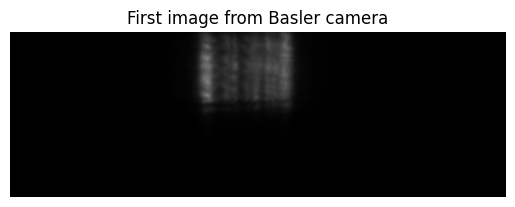

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(images[5], cmap='gray')
plt.title('First image from Basler camera')
plt.axis('off')
plt.show()


## Bender scan at position 13
We think we're on row 5 with 7 um shearing grating

In [41]:
# basler_camera.cam.acquire_time.set(.5)

basler_camera.cam.stage_sigs['acquire_time']  = 0.05
basler_camera.cam.stage_sigs['acquire_period'] = 1

In [42]:
basler_camera.cam.acquire_time.get()

0.5

In [43]:
from bluesky.plans import scan

RE(scan([basler_camera], Obender, -1484, -1484, 1))

('b16481ab-6f46-4b75-b49b-d89648aa09b8',)

In [44]:
uid = _
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
# see that /10ec should have been 10/ec et voila


In [58]:
%matplotlib qt5
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(images[0], cmap='gray')
plt.title('First image from Basler camera')
plt.colorbar()
plt.axis('off')
plt.show()


In [59]:
import imageio

# Save the first image in the images array as a TIFF file
imageio.imwrite('image_0.tiff', images[0])

In [56]:
plt.figure()
plt.plot(images[0])
plt.title('First image from Basler camera')
# plt.axis('off')
plt.show()

In [55]:
data2plot = np.fft.fft(images[0][:,1413])
data2plot = np.fft.fftshift(data2plot)
data2plot = np.abs(data2plot)

plt.figure()
plt.plot(data2plot)
plt.title('First image from Basler camera')
# plt.axis('off')
plt.show()

In [ ]:
plt.figure()
plt.plot(images[0][:,1400])
plt.title('First image from Basler camera')
# plt.axis('off')
plt.show()

## Bender Scan

In [62]:
from bluesky.plans import scan

RE(scan([basler_camera], Obender, -2000, 0.0, 11))



Transient Scan ID: 6     Time: 2026-03-20 11:24:38
Persistent Unique Scan ID: '2e99d328-b226-4996-b351-6351a52f7e9e'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.99152                    |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+------------+
|   seq_num |       time |  bender_um |
+-----------+------------+------------+
|         1 | 11:24:47.8 | -1999.98786 |
|         2 | 11:24:53.8 | -1800.01833 |
|         3 | 11:24:59.5 | -1600.01700 |
|         4 | 11:25:05.1 | -1400.01726 |
|         5 | 11:25:10.7 | -1200.01593 |
|         6 | 11:25:16.2 | -1000.01619 |
|         7 | 11:25:21.8 | -80

('2e99d328-b226-4996-b351-6351a52f7e9e',)

In [ ]:
uid = '5c28f39b-6fd2-4c14-a7a8-e4ffff5ce8a2'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
# see that /10ec should have been 10/ec et voila


In [ ]:
uid = '5c28f39b-6fd2-4c14-a7a8-e4ffff5ce8a2'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
# see that /10ec should have been 10/ec et voila


In [63]:
uid = _
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
# see that /10ec should have been 10/ec et voila


In [ ]:
for i in range(11):
    plt.figure(figsize=(15, 12))
    plt.imshow(images[i], cmap='gray')
    plt.title('First image from Basler camera')
    plt.colorbar()
    plt.axis('off')
    plt.show(block=True)

CA.Client.Exception...............................................
    Context: "192.168.10.124:41585"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Fri Mar 20 2026 16:38:26.399546031
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:44251"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 09:15:53.384697549
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:41915"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 09:30:37.128591438
..................................................................


In [ ]:
# 8keV, -1480um bending, scan the linear stage from 5 to 30mm in 251 steps
from bluesky.plans import scan
from time import sleep
mono_energy.move(7800)
mono_energy.move(8000)
bcs_linear_motor.set(0)
sleep(10)
uid = RE(scan([basler_camera], bcs_linear_motor, 5, 30, 251))
print(uid)

## Energy scan 

In [ ]:
import matplotlib.pyplot as plt
# magnification of the WFS camera setup
mag = 5
# pixel size of the camera in microns
px_cam_m = 2.4e-6 * 2 # we bin 2x2, so effective pixel size on camera is 4.8 um
# effective pixel size in the sample plane
px_img_m = px_cam_m/mag
stride_px = 0.1e-3/px_img_m
#print(f"Pixel stride in pixels: {stride_px:.1f} px")


db = tiled_client[uid]
data_list = db['primary']['basler_camera_image'].read()
# Calculate the height of the composite image
composite_height = int(data_list[0].shape[0] + (len(data_list) - 1) * stride_px)
composite_width = data_list[0].shape[1]

# Create an empty array for the composite image
composite_image = np.zeros((composite_height, composite_width), dtype=data_list[0].dtype)

x_composite_um = np.arange(composite_width)*px_img_m
y_composite_um = np.arange(composite_height)*px_img_m

# Add each image to the composite image with the specified vertical displacement
for idx, image in enumerate(data_list):
    start_y = int(idx * stride_px)
    end_y = start_y + image.shape[0]
    composite_image[start_y:end_y, :] += image

plt.imsave('../data/20260313_ALS531_WFS/linear_composite_image_8000.png', composite_image.T, cmap='gray')

In [ ]:
# plt.imshow(data_list[60], cmap='gray')
amplitude_sums = []
for data in data_list:
    fft = np.sum(np.abs(np.fft.fftshift(np.fft.fft(data[:, 700:], axis=0))), axis=1)
    amplitude_sums.append(fft[560] - fft[580])
plt.plot(amplitude_sums)
plt.show()

In [ ]:
data = data_list[84]
fft = np.fft.fftshift(np.fft.fft2(data))

plt.imshow(np.abs(data)**0.2, cmap='gray')
plt.show()

In [ ]:
bcs_linear_motor.set(13.3)

In [ ]:
# scan bender from 0 to -2000um in 10um steps
uid = RE(scan([basler_camera], Obender, 0, -2000, 211))

In [ ]:
uid = '67e37869-a3db-439d-b965-b3b70e50a698'
print(uid)